### **Download Dataset Strategy**

* Due to the large size of the dataset, the direct download from Kaggle might take a considerable amount of time. To optimize the process and enhance efficiency, we have decided to download the dataset directly onto Google Colab, where we can take advantage of its high-performance cloud-based environment. This way, we can ensure faster and more reliable downloads. Once the dataset is securely stored in the Google Colab environment, we will be able to utilize it efficiently for our analysis and modeling tasks without the need to repeatedly download the data. This strategic approach allows us to maximize productivity and focus on the core aspects of our project, making the most of the resources at our disposal. With the dataset readily accessible in Google Colab, we are well-equipped to perform data exploration, processing, and modeling with ease and effectiveness.

* #### **Dataset Souce:** https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification/datas

In [36]:

# Upload files from local machine to Google Colab
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rafaeldolores","key":"0ef0abe7a5567f8eb3832fc876320046"}'}

In [37]:
# Set up Kaggle API credentials in the Colab environment
!mkdir /root/.kaggle
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [38]:
# Download a Kaggle dataset with the specified dataset ID
!kaggle datasets download -d asdasdasasdas/garbage-classification

garbage-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [40]:
# Unzip a ZIP file
!unzip /content/garbage-classification.zip

Archive:  /content/garbage-classification.zip
replace Garbage classification/Garbage classification/cardboard/cardboard1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Garbage classification/Garbage classification/cardboard/cardboard1.jpg  
replace Garbage classification/Garbage classification/cardboard/cardboard10.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Garbage classification/Garbage classification/cardboard/cardboard10.jpg  
replace Garbage classification/Garbage classification/cardboard/cardboard100.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [41]:
# improt the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from glob import glob
import seaborn as sns
from tabulate import tabulate
import random
import os
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Map the images from train folder with train labels to form a DataFrame
def get_all_images_from_subdirectory_to_dataframe(path):
  configfiles = [os.path.join(dirpath, f)
      for dirpath, dirnames, files in os.walk(path)
      for f in files if f.endswith('.jpg')]
  images_list = [(i.split("/")[-2],i.split("/")[-1], i) for i in tqdm(configfiles)]
  return images_list

In [ ]:
dataset_dir = '/content/Garbage classification'

In [ ]:
df_list = get_all_images_from_subdirectory_to_dataframe(dataset_dir)
df = pd.DataFrame(data=df_list, columns=['Class', 'image_name', 'image_path'])

  0%|          | 0/2527 [00:00<?, ?it/s]

In [ ]:
df.head()

,Class,image_name,image_path
0,cardboard,cardboard285.jpg,/content/Garbage classification/Garbage classi...
1,cardboard,cardboard3.jpg,/content/Garbage classification/Garbage classi...
2,cardboard,cardboard97.jpg,/content/Garbage classification/Garbage classi...
3,cardboard,cardboard153.jpg,/content/Garbage classification/Garbage classi...
4,cardboard,cardboard181.jpg,/content/Garbage classification/Garbage classi...


In [ ]:
df.shape

(2527, 3)

In [ ]:
import random

# Write a function that will select n random images and display images along with its species
def plot_random_images(df, total_image=2):
    import matplotlib.image as mpimg
    fig, axes = plt.subplots(1, total_image,figsize=(14,2))
    images_data = list(zip(df['image_path'],df['Class']))
    samples = random.sample(images_data,total_image)
    for ax, (image, label) in zip(axes, samples):
        image = mpimg.imread(image)
        ax.set_axis_off()
        ax.imshow(image, cmap = 'binary')
        ax.set_title(f'{label}')

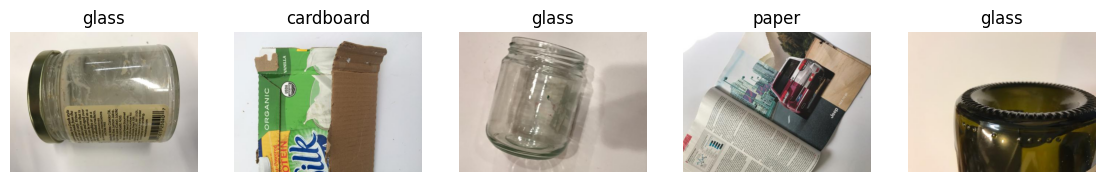

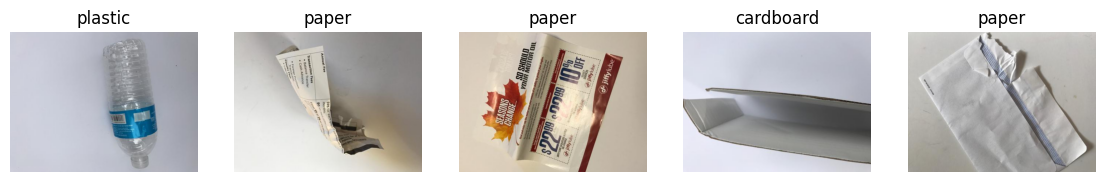

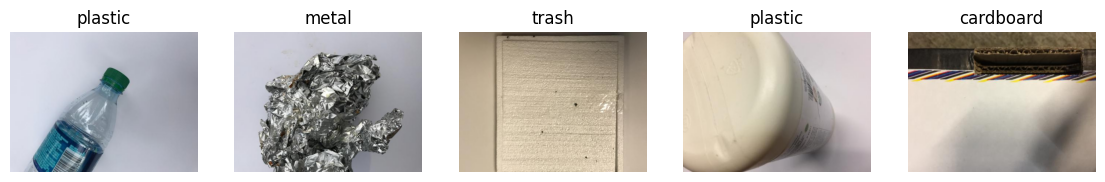

In [ ]:
plot_random_images(df, 5)
plot_random_images(df, 5)
plot_random_images(df, 5)

In [ ]:
def target_distribution(df_final, col):
    plt.figure(figsize=(17, 7))

    plt.subplot(1, 2, 1)

    # Updated colors
    c = ['#66CD00', '#FF0000', '#FFA500', '#FFFF00', '#00BFFF', '#8A2BE2']
    ax = df_final[col].value_counts().plot(kind='bar', color=c)

    plt.xlabel('Category', fontsize=16)
    plt.ylabel('Frequency of Target', fontsize=16)
    plt.xticks(size=12)
    plt.yticks(size=12)
    plt.title('Frequency Distribution of Target', fontsize=18)
    for p in ax.patches:
        ax.annotate(str(p.get_height()), (p.get_x() * 1.05, p.get_height() * 1.01), size=15)


    plt.subplot(1, 2, 2)

    # Updated explode values
    explode = [0.05] * 6
    df_final[col].value_counts().plot.pie(explode=explode, autopct='%1.2f%%', shadow=True, colors=c,
                                          textprops={'fontsize': 15, 'color': 'white'})
    plt.ylabel('target', fontsize=16)
    plt.title('Proportional Distribution of Target', fontsize=18)
    plt.legend()
    plt.show()

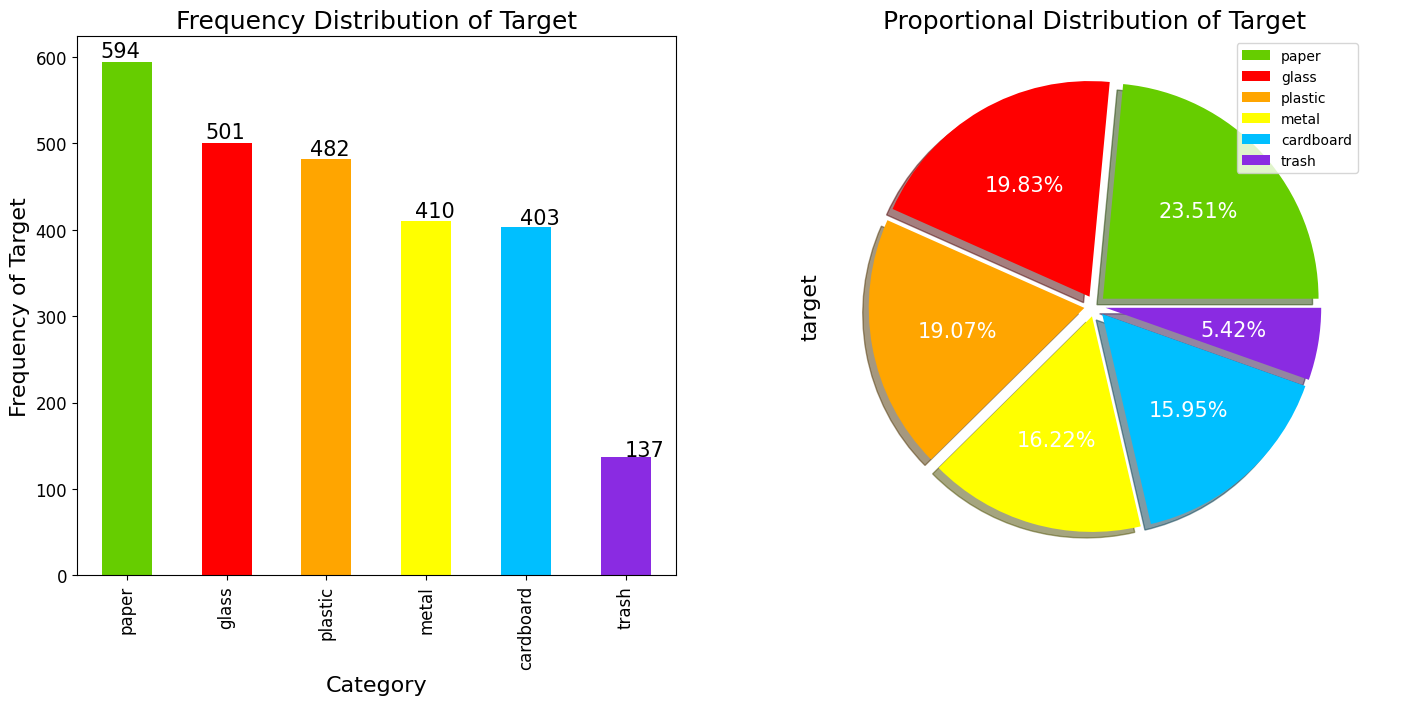

In [ ]:
target_distribution(df, 'Class')

In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
import tensorflow as tf

print(tf.__version__)
if 'COLAB_TPU_ADDR' in os.environ:
    print('Connected to TPU')
elif tf.test.gpu_device_name() is not '':
    print('Connected to GPU ' + tf.test.gpu_device_name())
else:
    print('Neither connected to a TPU nor a GPU')

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
    print('Select the Runtime → "Change runtime type" menu to enable a GPU accelerator, ')
    print('and then re-execute this cell.')
else:
    print(gpu_info)

2.14.0
Connected to GPU /device:GPU:0
Thu Nov  9 21:24:38 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   39C    P0    29W /  70W |    309MiB / 15360MiB |      1%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                  

In [ ]:
from sklearn.preprocessing import LabelEncoder

# convert the categorical values to numeric values
labelEncoder = LabelEncoder()
df['Class'] = labelEncoder.fit_transform(df['Class'])

In [ ]:
labelEncoder.classes_

array(['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'],
      dtype=object)

In [ ]:
from tqdm.auto import tqdm

height = 224
width = 224
channel = 3

def get_X_Y(df):
    images, labels = [], []
    # Iterate over image paths
    for img_path, target in tqdm(zip(df['image_path'], df['Class']), total=len(df)):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (height, width))  # Unify shape of all the images.

        images.append(img)
        labels.append(target)

    # Convert images and labels to numpy arrays
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.float32)

    return images, labels

In [ ]:
# Get X and y arrays using the get_X_Y function
X, y = get_X_Y(df)

  0%|          | 0/2527 [00:00<?, ?it/s]

In [ ]:
X.shape, y.shape

((2527, 224, 224, 3), (2527,))

In [ ]:
# Normalise all the images
def normalize_images(images):
  # convert into float32
  images = images.astype('float32')
  images /= 255.0
  return images

In [ ]:
# Normalize the images in X
X_norm = normalize_images(X)
print("done.")

done.


In [ ]:
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the data into training and remaining (validation + test) sets
# 80% for training, 10% for testing and validation
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.20, random_state=0, stratify=y)

# Splitting the remaining data into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.50, random_state=0, stratify=y_test)

# Printing the shapes of the datasets
print("Training Data:", X_train.shape)
print("Validation Data:", X_val.shape)
print("Test Data:", X_test.shape)


Training Data: (2021, 224, 224, 3)
Validation Data: (253, 224, 224, 3)
Test Data: (253, 224, 224, 3)


In [ ]:
print("Training Splition Data")
print(pd.Series(y_train).astype(int).value_counts())
print()
print("Testing Splition Data")
print(pd.Series(y_test).astype(int).value_counts())
print()
print("Validation Splition Data")
print(pd.Series(y_val).astype(int).value_counts())

Training Splition Data
3    475
1    401
4    385
2    328
0    322
5    110
dtype: int64

Testing Splition Data
3    60
1    50
4    48
0    41
2    41
5    13
dtype: int64

Validation Splition Data
3    59
1    50
4    49
2    41
0    40
5    14
dtype: int64


In [ ]:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

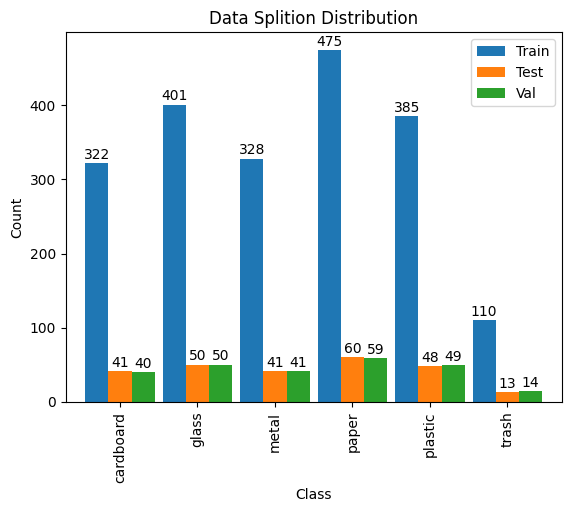

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create Pandas series objects and get the value counts
y_train_series = pd.Series(y_train).astype(int)
y_test_series = pd.Series(y_test).astype(int)
y_val_series = pd.Series(y_val).astype(int)

train_value_counts = y_train_series.map({0:"cardboard", 1:"glass", 2:"metal", 3:"paper", 4:"plastic", 5:"trash"}).value_counts()
test_value_counts = y_test_series.map({0:"cardboard", 1:"glass", 2:"metal", 3:"paper", 4:"plastic", 5:"trash"}).value_counts()
val_value_counts = y_val_series.map({0:"cardboard", 1:"glass", 2:"metal", 3:"paper", 4:"plastic", 5:"trash"}).value_counts()


# Create a Pandas DataFrame from the value counts
df = pd.DataFrame({'Train': train_value_counts, 'Test': test_value_counts,
                   'Val':val_value_counts})
# Create a grouped bar plot
ax = df.plot.bar(width=0.9)

# Loop over the bars and add the count number
for p in ax.containers:
    ax.bar_label(p, label_type='edge', padding=1)

# Set the labels and title
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_title('Data Splition Distribution')

plt.savefig("train_test_val.png", bbox_inches='tight')
# Show the plot
plt.show()


In [ ]:
from keras.utils import to_categorical

# Perform one-hot encoding on labels
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)
y_val_one_hot = to_categorical(y_val)

In [ ]:
# Get the list of Classes from a label encoder
Classes = list(labelEncoder.classes_)
Classes

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

## **Model Building**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# DATA AUGMENTATION
datagen = ImageDataGenerator(
    featurewise_center=False,  # set input mean to 0 over the dataset
    samplewise_center=False,  # set each sample mean to 0
    featurewise_std_normalization=False,  # divide inputs by std of the dataset
    samplewise_std_normalization=False,  # divide each input by its std
    zca_whitening=False,  # apply ZCA whitening
    rotation_range=0,  # randomly rotate images in the range (degrees, 0 to 180)
    width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
    height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
    horizontal_flip=True,  # randomly flip images
    vertical_flip=False,  # randomly flip images
)

In [ ]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNet

In [ ]:
  # Load the pre-trained model
  pretrained_model = MODEL(weights='imagenet', include_top=False, input_shape=(height, width, channel))

  # Freeze the pre-trained layers to prevent their weights from being updated during training
  for layer in pretrained_model.layers:
      layer.trainable = False

  # Create a new model by adding your custom layers on top of the model
  model = tf.keras.Sequential([
      pretrained_model,
      tf.keras.layers.GlobalAveragePooling2D(),
      tf.keras.layers.Dense(256, activation='relu'),
      tf.keras.layers.Dropout(0.3),
      tf.keras.layers.Dense(128, activation='relu'),
      tf.keras.layers.Dense(64, activation='relu'),
      tf.keras.layers.Dense(len(Classes), activation='softmax')
  ])

  # Compile and summarize the model
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

### **VGG16**

In [ ]:
model_vgg16 = LoadPretrainedModel(VGG16)
print(model_vgg16.summary())

58889256/58889256 [==============================] - 1s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               131328    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                82

In [ ]:
def TrainModel(model, epochs, batch_size, early_stopping, verbose):
  # Train the model with early stopping on train data and validate on test data
  history = model.fit(datagen.flow(X_train, y_train_one_hot, batch_size=batch_size),epochs=epochs,verbose=verbose,validation_data=(X_val, y_val_one_hot), callbacks=[early_stopping])
  return history

In [42]:
EPOCHS = 30
BATCH_SIZE = 64

# Define early stopping criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = TrainModel(model_vgg16, EPOCHS, BATCH_SIZE, early_stopping, verbose = 1)

Epoch 1/30
32/32 [==============================] - 27s 851ms/step - loss: 0.8988 - accuracy: 0.6526 - val_loss: 0.8344 - val_accuracy: 0.6601
Epoch 2/30
32/32 [==============================] - 26s 801ms/step - loss: 0.8298 - accuracy: 0.6858 - val_loss: 0.8394 - val_accuracy: 0.6522
Epoch 3/30
32/32 [==============================] - 27s 845ms/step - loss: 0.7862 - accuracy: 0.6997 - val_loss: 0.7656 - val_accuracy: 0.6759
Epoch 4/30
32/32 [==============================] - 26s 816ms/step - loss: 0.7561 - accuracy: 0.7209 - val_loss: 0.7164 - val_accuracy: 0.7431
Epoch 5/30
32/32 [==============================] - 26s 823ms/step - loss: 0.7102 - accuracy: 0.7373 - val_loss: 0.7142 - val_accuracy: 0.7273
Epoch 6/30
32/32 [==============================] - 27s 832ms/step - loss: 0.7094 - accuracy: 0.7328 - val_loss: 0.7055 - val_accuracy: 0.7391
Epoch 7/30
32/32 [==============================] - 26s 811ms/step - loss: 0.6577 - accuracy: 0.7590 - val_loss: 0.7384 - val_accuracy: 0.7352

In [43]:
def plotGraphs(history):
    training_accuracy = history.history['accuracy']
    validation_accuracy = history.history['val_accuracy']

    training_loss = history.history['loss']
    validation_loss = history.history['val_loss']

    epochs_range=range(len(history.history['loss']))

    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
    plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, training_loss, label='Training Loss')
    plt.plot(epochs_range, validation_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

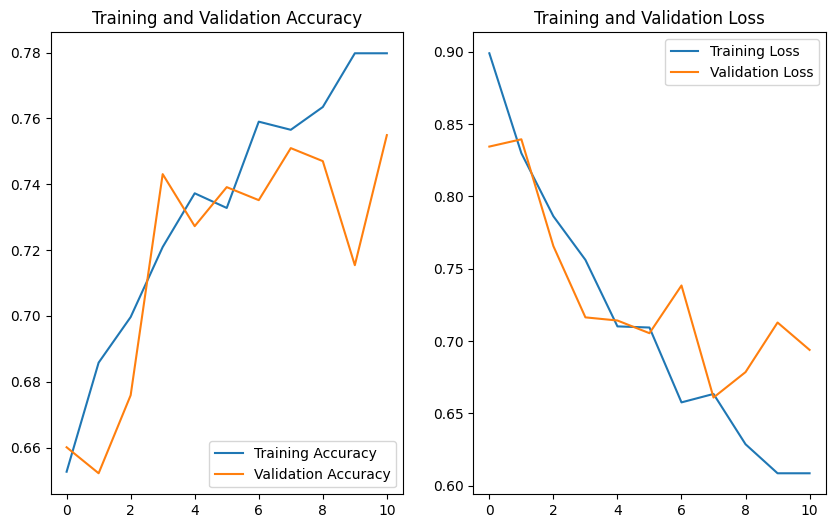

In [44]:
plotGraphs(history)

In [45]:
import numpy as np
from sklearn.metrics import accuracy_score

def GetPredictionTestingData(model):
    # Perform predictions on the validation set
    y_pred_test = model.predict(X_test)
    y_pred_test = np.argmax(np.round(y_pred_test), axis=1)

    # Perform predictions on the training set
    y_pred_train = model.predict(X_train)
    y_pred_train = np.argmax(np.round(y_pred_train), axis=1)

    # Calculate and print training accuracy
    accuracy_train = accuracy_score(y_train, y_pred_train)
    print("Training Accuracy:", accuracy_train)

    # Calculate and print testing accuracy
    accuracy_test = accuracy_score(y_test, y_pred_test)
    print("Testing Accuracy:", accuracy_test)

    return y_pred_test, y_pred_train

In [46]:
y_pred, y_pred_train = GetPredictionTestingData(model_vgg16)

64/64 [==============================] - 10s 159ms/step
Training Accuracy: 0.7570509648688768
Testing Accuracy: 0.6679841897233202


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [48]:
def results(model_name, y_pred, y_test, y_train,y_pred_train):
    target_names = ["{}".format(Classes[i]) for i in range(len(Classes))] # Define target names for classification report
    accuracy = round(accuracy_score(y_pred, y_test)*100,4)
    train_accuracy = round(accuracy_score(y_pred_train, y_train)*100,4)

    precision = round(precision_score(y_pred, y_test, average='macro')*100,4)
    recall = round(recall_score(y_pred, y_test, average='macro')*100,4)
    f1_scr = round(f1_score(y_pred, y_test, average='macro')*100,4)


    print("\nTraining Accuracy: {}%".format(train_accuracy))
    print("Testing Accuracy: {}%".format(accuracy))

    print("Precision: {}%".format(precision))
    print("Recall: {}%".format(recall))
    print("F1-Score: {}%".format(f1_scr))
    print()
    print("Classification Report:")
    print(classification_report(y_pred, y_test, target_names=target_names))
    print()
    print("Confusion Matrix:")
    fig, ax = plt.subplots(figsize=(7,5))
    ConfusionMatrixDisplay.from_predictions(y_pred, y_test,
                                            ax=ax,
                                            display_labels=target_names,
                                            xticks_rotation='vertical')
    plt.show()

    return {
        'Model':model_name,
        'Training Accuracy': train_accuracy,
        'Testing Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1_scr
    }

In [49]:
def GetModelResultsInDataFrame(res):
  # Convert the dictionary to a DataFrame
  return pd.DataFrame.from_dict([res]).set_index('Model')


Training Accuracy: 75.7051%
Testing Accuracy: 66.7984%
Precision: 62.5968%
Recall: 69.1067%
F1-Score: 62.185%

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.95      0.48      0.63        82
       glass       0.46      0.79      0.58        29
       metal       0.78      0.73      0.75        44
       paper       0.67      0.87      0.75        46
     plastic       0.67      0.68      0.67        47
       trash       0.23      0.60      0.33         5

    accuracy                           0.67       253
   macro avg       0.63      0.69      0.62       253
weighted avg       0.75      0.67      0.67       253


Confusion Matrix:


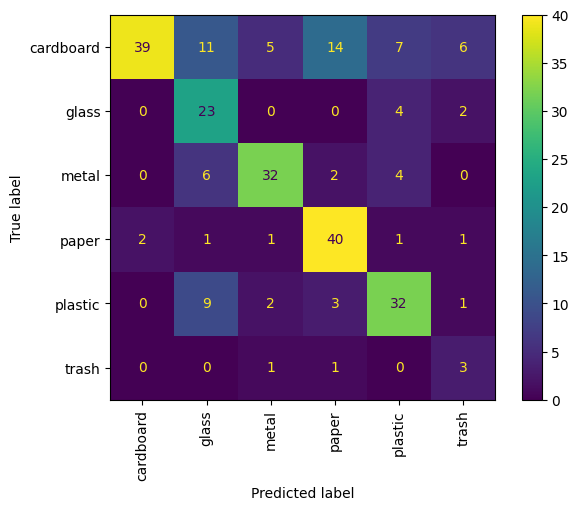

,Training Accuracy,Testing Accuracy,Precision,Recall,F1
Model,,,,,
VGG16,75.7051,66.7984,62.5968,69.1067,62.185


In [50]:
vgg16_res = GetModelResultsInDataFrame(results("VGG16", y_pred, y_test, y_train, y_pred_train))
vgg16_res

### **DenseNet201**

In [51]:
model_densenet201 = LoadPretrainedModel(DenseNet201)
print(model_densenet201.summary())
history = TrainModel(model_densenet201, EPOCHS, BATCH_SIZE, early_stopping, verbose =1 )

74836368/74836368 [==============================] - 0s 0us/step
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet201 (Functional)    (None, 7, 7, 1920)        18321984  
                                                                 
 global_average_pooling2d_1  (None, 1920)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_4 (Dense)             (None, 256)               491776    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 64)                

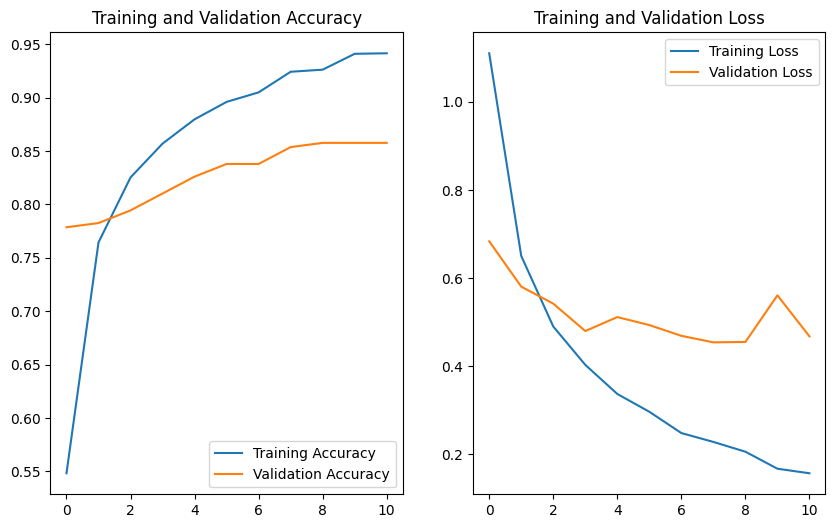

64/64 [==============================] - 12s 185ms/step
Training Accuracy: 0.9683325086590797
Testing Accuracy: 0.841897233201581


In [52]:
plotGraphs(history)
y_pred, y_pred_train = GetPredictionTestingData(model_densenet201)


Training Accuracy: 96.8333%
Testing Accuracy: 84.1897%
Precision: 78.6545%
Recall: 82.6516%
F1-Score: 79.3562%

Classification Report:
              precision    recall  f1-score   support

   cardboard       1.00      0.75      0.85        55
       glass       0.90      0.80      0.85        56
       metal       0.78      0.89      0.83        36
       paper       0.88      0.95      0.91        56
     plastic       0.77      0.86      0.81        43
       trash       0.38      0.71      0.50         7

    accuracy                           0.84       253
   macro avg       0.79      0.83      0.79       253
weighted avg       0.86      0.84      0.85       253


Confusion Matrix:


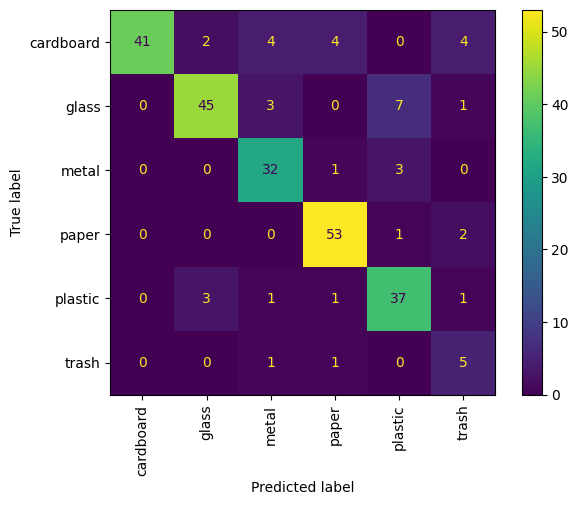

,Training Accuracy,Testing Accuracy,Precision,Recall,F1
Model,,,,,
DenseNet201,96.8333,84.1897,78.6545,82.6516,79.3562


In [53]:
densenet201_res = GetModelResultsInDataFrame(results("DenseNet201", y_pred, y_test, y_train, y_pred_train))
densenet201_res

### **Models Evaluation**

In [54]:
df_all_models = pd.concat([vgg16_res, densenet201_res])
models_pd_ = df_all_models.reset_index()
models_pd_

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1
0,VGG16,75.7051,66.7984,62.5968,69.1067,62.1850
1,DenseNet201,96.8333,84.1897,78.6545,82.6516,79.3562


* DenseNet201 model is better lets save this model.

### **Save & Load Model**

In [55]:
# serialize model to JSON
from keras.models import model_from_json
model_json = model_densenet201.to_json()
with open("/content/drive/MyDrive/GarbageModel/garbage_model.json", "w") as json_file:
    json_file.write(model_json)
# serialize weights to HDF5
model_densenet201.save_weights("/content/drive/MyDrive/GarbageModel/garbage_model.h5")
print("Saved model to disk")

Saved model to disk


In [56]:
from keras.models import model_from_json

In [57]:
# load json and create model
json_file = open('/content/drive/MyDrive/GarbageModel/garbage_model.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)
# load weights into new model
loaded_model.load_weights("/content/drive/MyDrive/GarbageModel/garbage_model.h5")
print("Loaded model from disk")

Loaded model from disk


### **Image Prediction**

In [58]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [60]:
 def image_prediction(path, model):
    mask_label = {0: "cardboard", 1: "glass", 2: "metal", 3: "paper", 4: "plastic", 5: "trash"}
    sample_mask_img = cv2.imread(path)
    img = cv2.resize(sample_mask_img, (224, 224))
    sample_mask_img = np.reshape(img, [1, 224, 224, 3])
    sample_mask_img = sample_mask_img / 255.0
    prediction = model.predict(sample_mask_img, verbose=0)
    label = np.argmax(prediction)
    probability = prediction[0][label]
    plt.imshow(img)
    plt.title(f"Predicted: {mask_label[label]}\nProbability: {probability:.2f}", fontsize=15)
    plt.show()


In [61]:
def image_prediction(path, model):
    mask_label = {0: "cardboard", 1: "glass", 2: "metal", 3: "paper", 4: "plastic", 5: "trash"}
    sample_mask_img = cv2.imread(path)
    img = cv2.resize(sample_mask_img, (224, 224))
    sample_mask_img = np.reshape(img, [1, 224, 224, 3])
    sample_mask_img = sample_mask_img / 255.0
    prediction = model.predict(sample_mask_img, verbose=0)
    labels = [mask_label[i] for i in range(len(mask_label))]
    probabilities = prediction[0]
    label = np.argmax(prediction)
    probability = probabilities[label]
    plt.imshow(img)
    title = f"Predicted: {mask_label[label]}\n"
    title += "Class Probabilities:\n"
    for i in range(len(mask_label)):
      title += f"{mask_label[i]}: {probabilities[i]:.2f} "
      if i%3==1:
        title += f"\n"
    plt.title(title, fontsize=12)
    plt.show()

    text = ''
    if mask_label[label]=='trash':
      text = 'Non-recylable'
    else:
      text = 'Recylable'
    return {"Image":path, "Prediction":mask_label[label], 'Probability':probability, 'Comments':text}

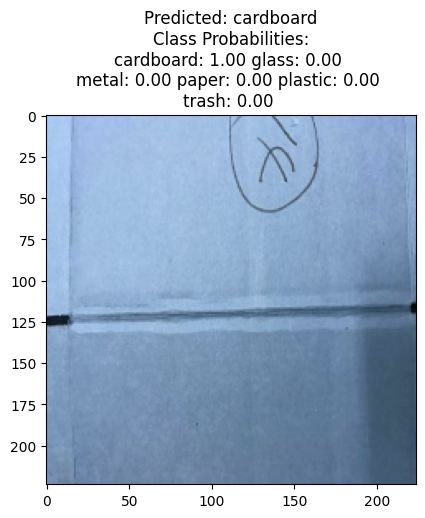

{'Image': '/content/garbage classification/Garbage classification/cardboard/cardboard1.jpg',
 'Prediction': 'cardboard',
 'Probability': 0.99837315,
 'Comments': 'Recylable'}

In [62]:
image_prediction("/content/garbage classification/Garbage classification/cardboard/cardboard1.jpg", loaded_model)

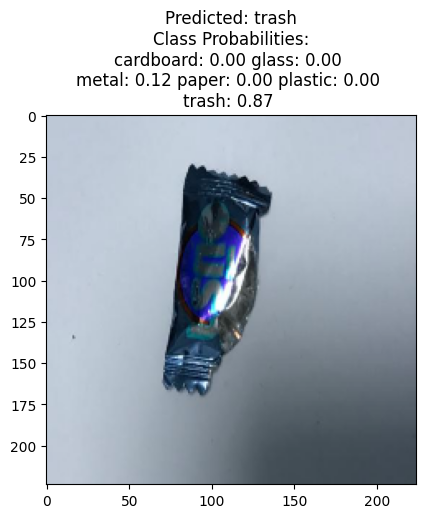

{'Image': '/content/garbage classification/Garbage classification/trash/trash10.jpg',
 'Prediction': 'trash',
 'Probability': 0.8703541,
 'Comments': 'Non-recylable'}

In [63]:
image_prediction("/content/garbage classification/Garbage classification/trash/trash10.jpg", loaded_model)

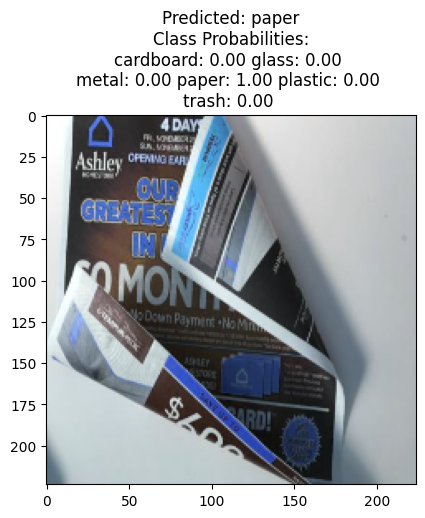

{'Image': '/content/garbage classification/Garbage classification/paper/paper165.jpg',
 'Prediction': 'paper',
 'Probability': 0.99921465,
 'Comments': 'Recylable'}

In [64]:
image_prediction("/content/garbage classification/Garbage classification/paper/paper165.jpg", loaded_model)